# Project Overview

This notebook documents the end-to-end workflow for the project, including data handling, analysis, modeling, and results.

## Objectives
- Define the problem statement and expected outcomes.
- Prepare and validate the dataset for analysis.
- Build and evaluate the solution using reproducible steps.
- Summarize findings and recommended next actions.

## Project Scope
- In scope: data preprocessing, exploratory analysis, implementation, evaluation, and reporting.
- Out of scope: production deployment and long-term monitoring (unless added later).

## Workflow Summary
1. **Data Loading** – Import source data and verify schema.
2. **Data Cleaning** – Handle missing values, duplicates, and inconsistent formats.
3. **Exploratory Analysis** – Identify distributions, trends, and correlations.
4. **Feature/Logic Preparation** – Create required transformations and inputs.
5. **Modeling or Core Implementation** – Train/test or implement project logic.
6. **Evaluation** – Measure performance using relevant metrics.
7. **Conclusion** – Capture insights, limitations, and next steps.

## Tools & Environment
- Python (Jupyter Notebook)
- Common libraries for data manipulation, visualization, and modeling
- Version-controlled, reproducible notebook workflow

## Expected Deliverables
- Clean and documented notebook
- Key visualizations and/or performance tables
- Final summary with actionable insights

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# Load the Dataset

In [3]:
df = pd.read_csv('datafile.csv')
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


# Remove the duplicates

In [4]:
print("Number of duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.head()

Number of duplicate rows: 17


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


# Create Histogram of a traffic volume

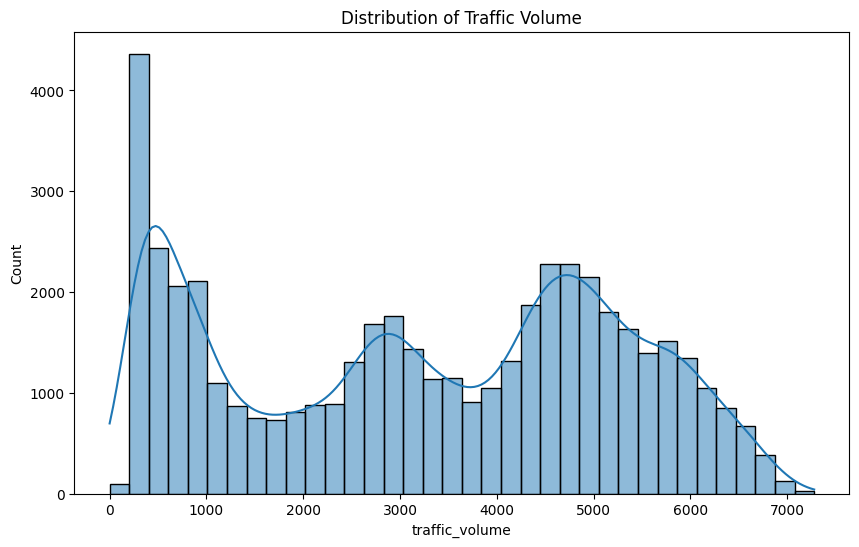

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['traffic_volume'],kde=True)
plt.title('Distribution of Traffic Volume')
plt.show()

# Get Date and Time

In [9]:
# Safe to rerun: only parse when raw date_time exists
if 'date_time' in df.columns:
    # Parse timestamps robustly: first try day-first format, then fallback to mixed parsing
    parsed_dt = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M', errors='coerce')
    fallback_mask = parsed_dt.isna()
    if fallback_mask.any():
        parsed_dt.loc[fallback_mask] = pd.to_datetime(
            df.loc[fallback_mask, 'date_time'],
            format='mixed',
            dayfirst=True,
            errors='coerce'
        )

    if parsed_dt.isna().any():
        print(f"Warning: {parsed_dt.isna().sum()} rows have unparseable date_time values and will remain NaT.")

    df['date_time'] = parsed_dt
    df['day'] = df['date_time'].dt.day_name()
    df['month'] = df['date_time'].dt.month
    df['year'] = df['date_time'].dt.year
    df['hour'] = df['date_time'].dt.hour

    df.drop('date_time', axis=1, inplace=True)
else:
    print("date_time not found. It was likely already processed in a previous run.")

df.head()

date_time not found. It was likely already processed in a previous run.


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,day,month,year,hour
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,Tuesday,10,2012,9
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,Tuesday,10,2012,10
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,Tuesday,10,2012,11
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,Tuesday,10,2012,12
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,Tuesday,10,2012,13


# Convert Categorical Columns to Numerical

In [10]:
df = pd.get_dummies( df, columns=list(set(df.columns) - set(df._get_numeric_data().columns)) )

# Create input and output parameters

In [11]:
x = df.drop('traffic_volume', axis =1)
y = df['traffic_volume']

# Split Training and Testing Data

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.85, shuffle=True, random_state=42)

# Build the model

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

# Train the Models

In [15]:
for model in models.values():
    model.fit(x_train, y_train)    

In [17]:
model_list = []
train_r2_scores = []
test_r2_scores = []
train_mse_scores = []
test_mse_scores = []
for model_name, model in models.items():
    pred_train = model.predict(x_train)
    pred_test = model.predict(x_test)
    model_list.append(model_name)

    train_r2_scores.append(r2_score(y_train, pred_train))
    test_r2_scores.append(r2_score(y_test, pred_test))

    train_mse_scores.append(mean_squared_error(y_train, pred_train))
    test_mse_scores.append(mean_squared_error(y_test, pred_test))

# Save the Models

In [19]:
for model_name, model in models.items():
    file_path = f'{model_name.replace(" ", "_").lower()}_model.pkl'
    joblib.dump(model, file_path)
    print(f"Saved {model_name} to {file_path}")

Saved Linear Regression to linear_regression_model.pkl
Saved Decision Tree to decision_tree_model.pkl
Saved Random Forest to random_forest_model.pkl


# Load And Use the Models

In [ ]:
loaded_models = []

for i in range(len(model_list)):
    file_path = f'{model_list[i].replace(" ", "_").lower()}_model.pkl'
    loaded_model = joblib.load(file_path)
    loaded_models.append(loaded_model)
    print(f"Loaded {model_list[i]} from {file_path}")

    

Loaded Linear Regression from linear_regression_model.pkl
Loaded Decision Tree from decision_tree_model.pkl
Loaded Random Forest from random_forest_model.pkl


In [24]:
# Test on first 10 samples (WITHOUT overwriting y_test)
sample_x = x_test.iloc[:10]
sample_y = y_test.iloc[:10]

print("=== Predictions on First 10 Test Samples ===")
for model_name, model in zip(model_list, loaded_models):
    prediction = model.predict(sample_x)
    mse = mean_squared_error(sample_y, prediction)
    print(f"{model_name} MSE (10 samples): {mse}")

=== Predictions on First 10 Test Samples ===
Linear Regression MSE (10 samples): 2155274.777343391
Decision Tree MSE (10 samples): 177589.1
Random Forest MSE (10 samples): 264159.7089399999


In [27]:
# Now evaluate on the FULL test set
for model_name, model in zip(model_list, loaded_models):
    prediction = model.predict(x_test)
    mse = mean_squared_error(y_test, prediction)
    print(f"{model_name} Full Test MSE: {mse}")

Linear Regression Full Test MSE: 19976500.278559916
Decision Tree Full Test MSE: 288065.29049661086
Random Forest Full Test MSE: 165953.36563653604
